## In this notebook have applied different regression algorithms and drew a relation how all the others models are performing

### Import Library

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/srisyra02/spotify-music-artist-streaming-analytics/Spotify Streaming Performance Dataset.csv


### Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('/kaggle/input/datasets/srisyra02/spotify-music-artist-streaming-analytics/Spotify Streaming Performance Dataset.csv')

## Preprocessing

In [3]:
df.head()

,Artist Name,Sex,Country of Origin,Primary Language,Primary Genre,Artist Type,Debut Year,Total Streams (in millions),Lead Streams (in millions),Feature Streams (in millions),Solo Streams (in millions),% of Solo Streams,Collaborative Streams (in millions),% of Collaborative Streams
0,Drake,Male,Canada,English,Hip-Hop,Solo,2006,137492.1,94851.1,42640.9,53323.9,38.783246,84168.2,61.216754
1,Taylor Swift,Female,United States,English,Pop,Solo,2006,127861.0,126177.3,1683.8,113421.5,88.706877,14439.5,11.293123
2,Bad Bunny,Male,United States,Spanish,Reggaeton,Solo,2013,125899.8,82189.3,43710.5,48887.0,38.830086,77012.8,61.169914
3,The Weeknd,Male,Canada,English,R&B,Solo,2009,95703.2,77189.4,18513.8,51020.0,53.310652,44683.2,46.689348
4,Justin Bieber,Male,Canada,English,Pop,Solo,2009,78104.4,48316.2,29788.2,29638.3,37.947030,48466.1,62.052970


In [4]:
df.tail()

,Artist Name,Sex,Country of Origin,Primary Language,Primary Genre,Artist Type,Debut Year,Total Streams (in millions),Lead Streams (in millions),Feature Streams (in millions),Solo Streams (in millions),% of Solo Streams,Collaborative Streams (in millions),% of Collaborative Streams
495,The Cure,Male,United Kingdom,English,Rock,Group,1979,7034.1,7035.0,3.3,6940.1,98.663653,94.0,1.336347
496,The Marías,Mixed,United States,English,Pop,Group,2017,7029.1,5774.4,1261.4,5705.9,81.175399,1323.2,18.824601
497,Limp Bizkit,Male,United States,English,Nu Metal,Group,1997,7018.9,7018.4,5.4,6806.0,96.966761,212.9,3.033239
498,Korn,Male,United States,English,Metal,Group,1994,6976.4,4188.4,2798.5,6414.9,91.951436,561.5,8.048564
499,Omar Courtz,Male,United States,Spanish,Reggaeton,Solo,2017,6972.0,6956.0,20.3,1876.2,26.910499,5095.8,73.089501


In [5]:
df.shape

(500, 14)

In [6]:
df.columns

Index(['Artist Name', 'Sex', 'Country of Origin', 'Primary Language',
       'Primary Genre', ' Artist Type', 'Debut Year',
       'Total Streams (in millions)', 'Lead Streams (in millions)',
       'Feature Streams (in millions)', 'Solo Streams (in millions)',
       '% of Solo Streams', 'Collaborative Streams (in millions)',
       '% of Collaborative Streams'],
      dtype='object')

In [7]:
df.dtypes

Artist Name                             object
Sex                                     object
Country of Origin                       object
Primary Language                        object
Primary Genre                           object
 Artist Type                            object
Debut Year                               int64
Total Streams (in millions)            float64
Lead Streams (in millions)             float64
Feature Streams (in millions)          float64
Solo Streams (in millions)             float64
% of Solo Streams                      float64
Collaborative Streams (in millions)    float64
% of Collaborative Streams             float64
dtype: object

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Artist Name                          500 non-null    object 
 1   Sex                                  500 non-null    object 
 2   Country of Origin                    500 non-null    object 
 3   Primary Language                     500 non-null    object 
 4   Primary Genre                        500 non-null    object 
 5    Artist Type                         500 non-null    object 
 6   Debut Year                           500 non-null    int64  
 7   Total Streams (in millions)          500 non-null    float64
 8   Lead Streams (in millions)           500 non-null    float64
 9   Feature Streams (in millions)        500 non-null    float64
 10  Solo Streams (in millions)           500 non-null    float64
 11  % of Solo Streams               

In [9]:
df.isnull().sum()

Artist Name                            0
Sex                                    0
Country of Origin                      0
Primary Language                       0
Primary Genre                          0
 Artist Type                           0
Debut Year                             0
Total Streams (in millions)            0
Lead Streams (in millions)             0
Feature Streams (in millions)          0
Solo Streams (in millions)             0
% of Solo Streams                      0
Collaborative Streams (in millions)    0
% of Collaborative Streams             0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,Debut Year,Total Streams (in millions),Lead Streams (in millions),Feature Streams (in millions),Solo Streams (in millions),% of Solo Streams,Collaborative Streams (in millions),% of Collaborative Streams
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,2005.346000,16817.610200,12141.734000,4681.289000,8324.397600,50.613084,8493.212600,49.386916
std,13.312578,14845.197632,11844.675186,5952.827762,9589.010168,33.762147,9612.491536,33.762147
min,1939.000000,6972.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2001.750000,8768.175000,6489.750000,696.500000,2519.775000,20.117951,2015.650000,16.860219
50%,2009.000000,11923.250000,8716.350000,3005.600000,6472.950000,47.062829,6592.250000,52.937171
75%,2014.000000,18020.050000,13456.900000,6093.350000,10115.550000,83.139781,11019.575000,79.882049
max,2023.000000,137492.100000,126177.300000,43710.500000,113421.500000,100.000000,84168.200000,100.000000


## EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

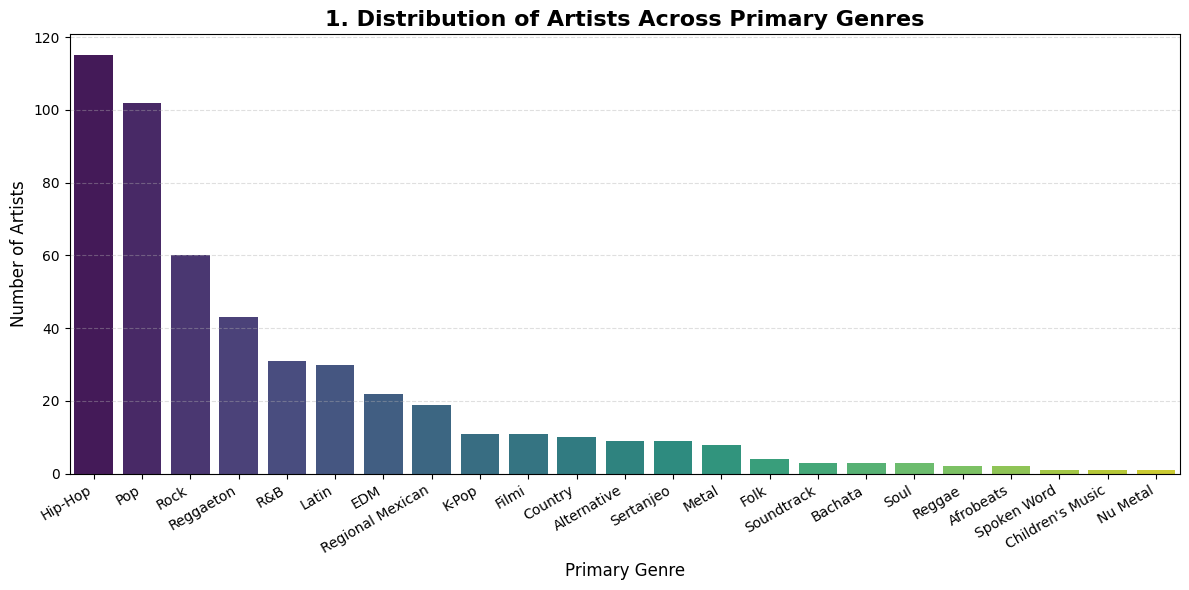

In [13]:
fig = plt.figure(figsize=(12, 6))
sns.countplot(data=df,x='Primary Genre',order=df['Primary Genre'].value_counts().index,palette='viridis')
plt.title(f'{plot_no}. Distribution of Artists Across Primary Genres',fontsize=16,fontweight='bold')
plt.xlabel('Primary Genre', fontsize=12)
plt.ylabel('Number of Artists', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)
show_fig()
plot_no += 1

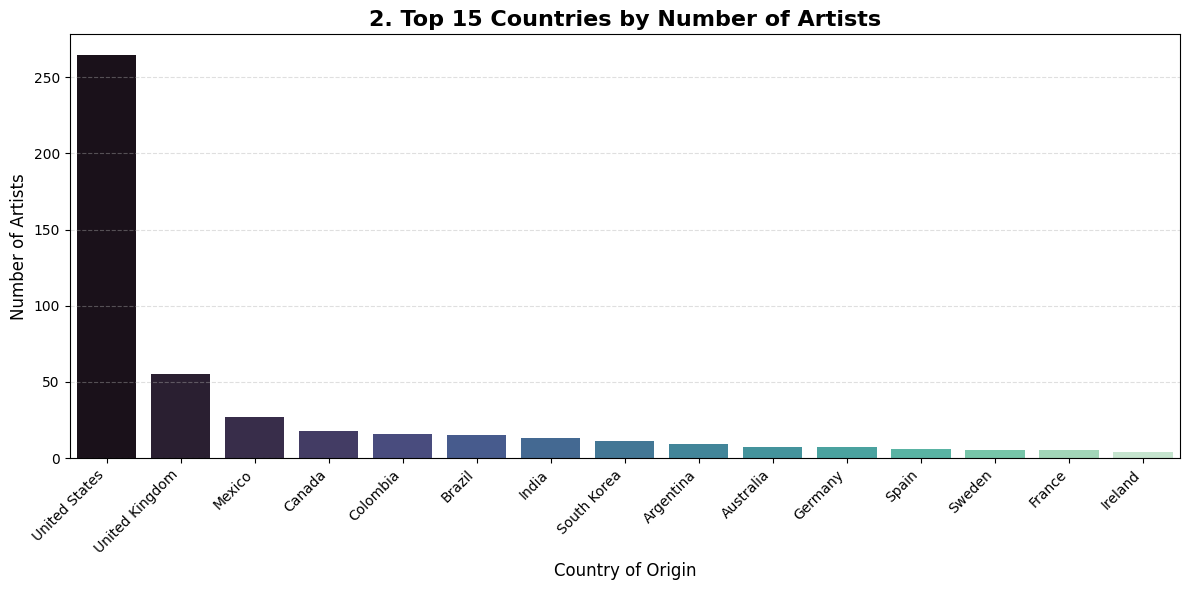

In [14]:
fig = plt.figure(figsize=(12, 6))
sns.countplot(
    data=df,
    x='Country of Origin',
    order=df['Country of Origin'].value_counts().head(15).index,
    palette='mako')
plt.title(
    f'{plot_no}. Top 15 Countries by Number of Artists',
    fontsize=16,
    fontweight='bold')
plt.xlabel('Country of Origin', fontsize=12)
plt.ylabel('Number of Artists', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)
show_fig()
plot_no += 1

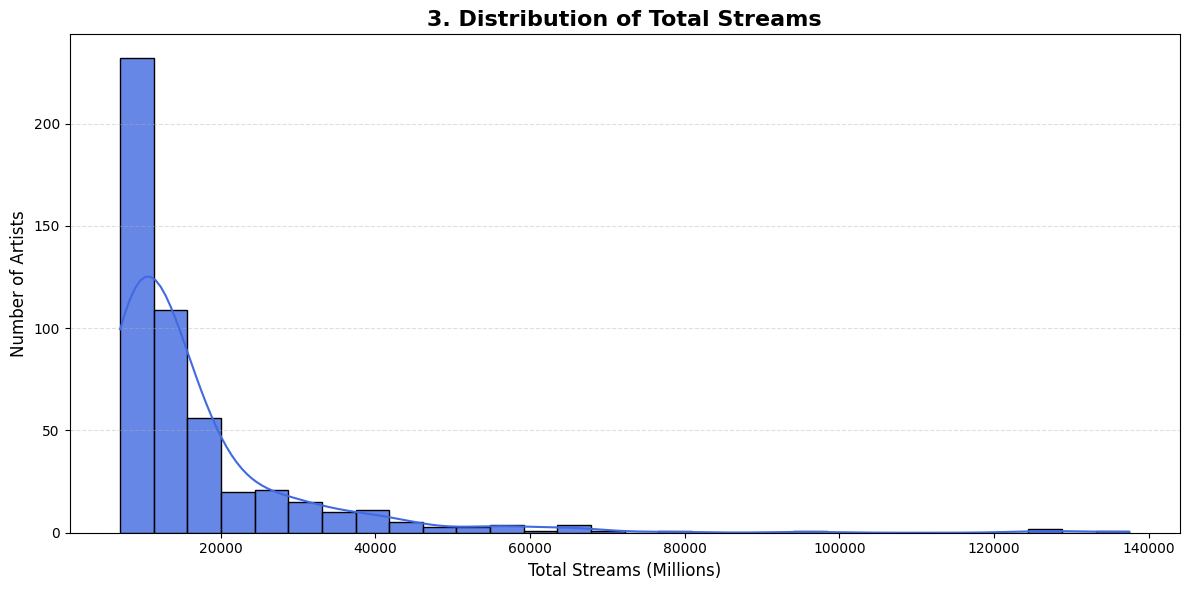

In [15]:
fig = plt.figure(figsize=(12, 6))
sns.histplot(
    data=df,
    x='Total Streams (in millions)',
    bins=30,
    kde=True,
    color='royalblue',
    edgecolor='black',
    alpha=0.8)
plt.title(f'{plot_no}. Distribution of Total Streams',
    fontsize=16,fontweight='bold')
plt.xlabel('Total Streams (Millions)', fontsize=12)
plt.ylabel('Number of Artists', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)
show_fig()
plot_no += 1

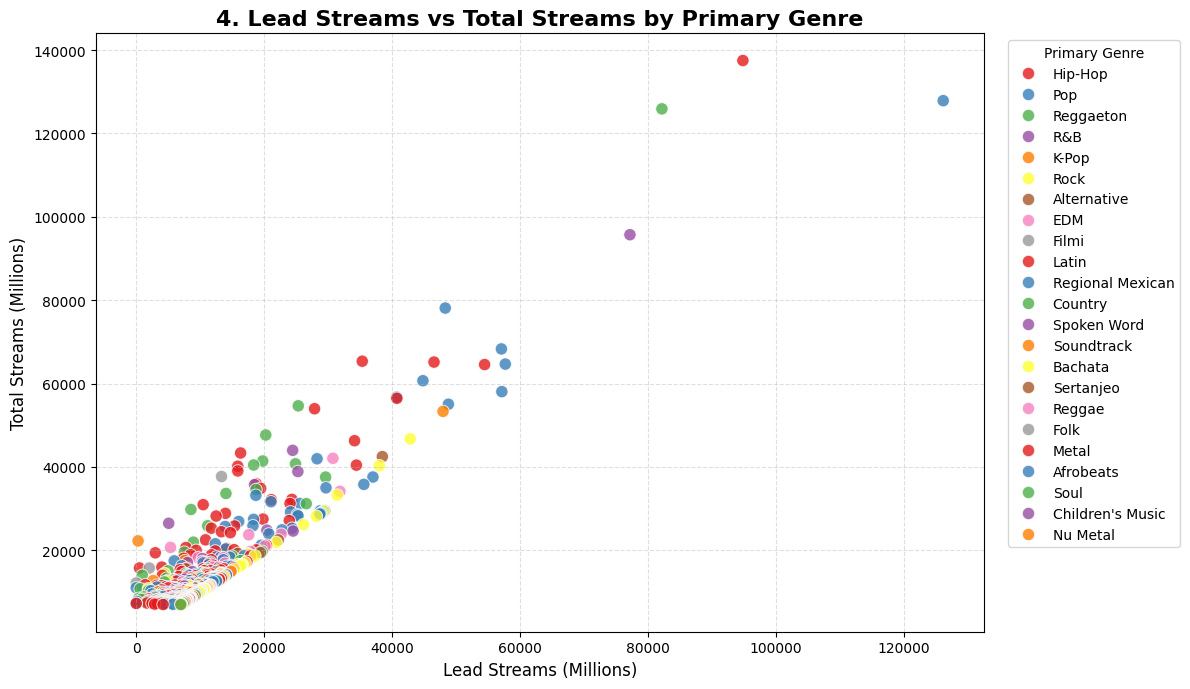

In [16]:
fig = plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df,
    x='Lead Streams (in millions)',
    y='Total Streams (in millions)',
    hue='Primary Genre',
    palette='Set1',
    s=80,
    alpha=0.8
)

plt.title(
    f'{plot_no}. Lead Streams vs Total Streams by Primary Genre',
    fontsize=16,
    fontweight='bold'
)
plt.xlabel('Lead Streams (Millions)', fontsize=12)
plt.ylabel('Total Streams (Millions)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='Primary Genre', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()

show_fig()
plot_no += 1

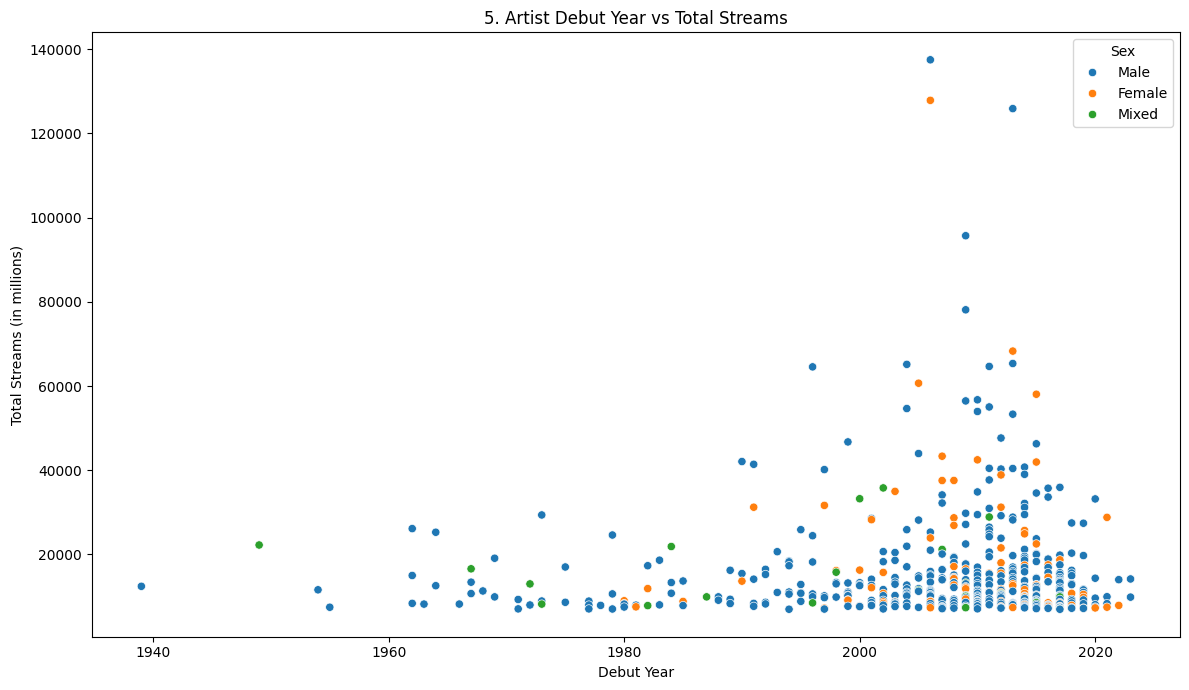

In [17]:
fig = plt.figure(figsize=(12,7))
sns.scatterplot(data=df, x='Debut Year', y='Total Streams (in millions)', hue='Sex')
plt.title(f'{plot_no}. Artist Debut Year vs Total Streams')
show_fig()
plot_no += 1

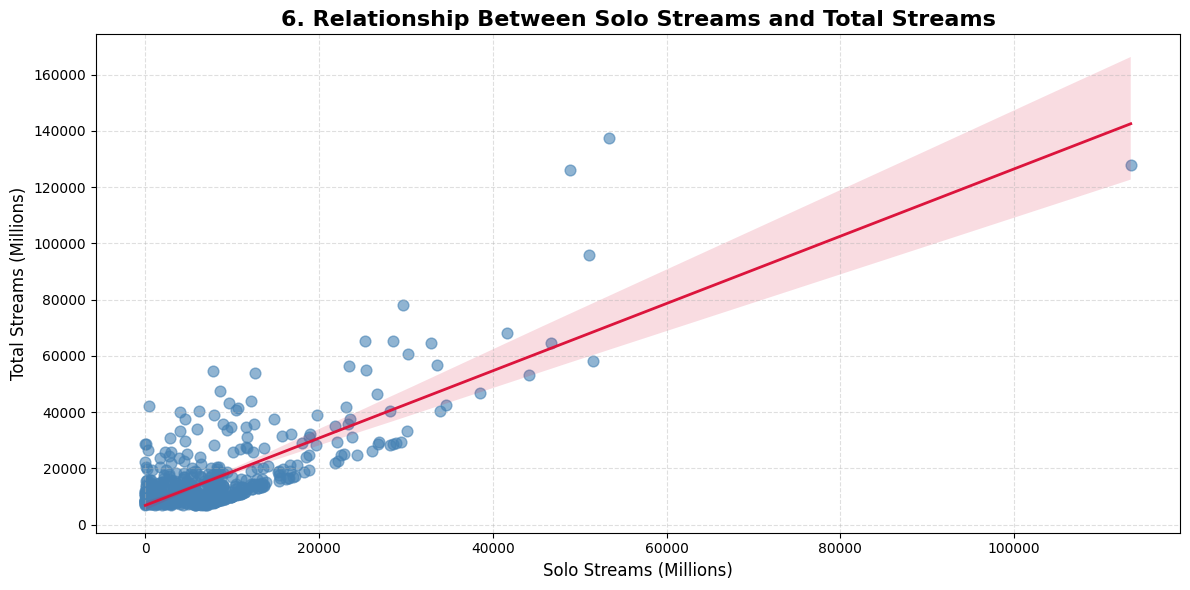

In [18]:
fig = plt.figure(figsize=(12, 6))
sns.regplot(data=df,x='Solo Streams (in millions)',y='Total Streams (in millions)',
    scatter_kws={
        'alpha': 0.6,
        's': 60,
        'color': 'steelblue'},
    line_kws={
        'color': 'crimson',
        'linewidth': 2})
plt.title(
    f'{plot_no}. Relationship Between Solo Streams and Total Streams',
    fontsize=16,fontweight='bold')
plt.xlabel('Solo Streams (Millions)', fontsize=12)
plt.ylabel('Total Streams (Millions)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
show_fig()
plot_no += 1

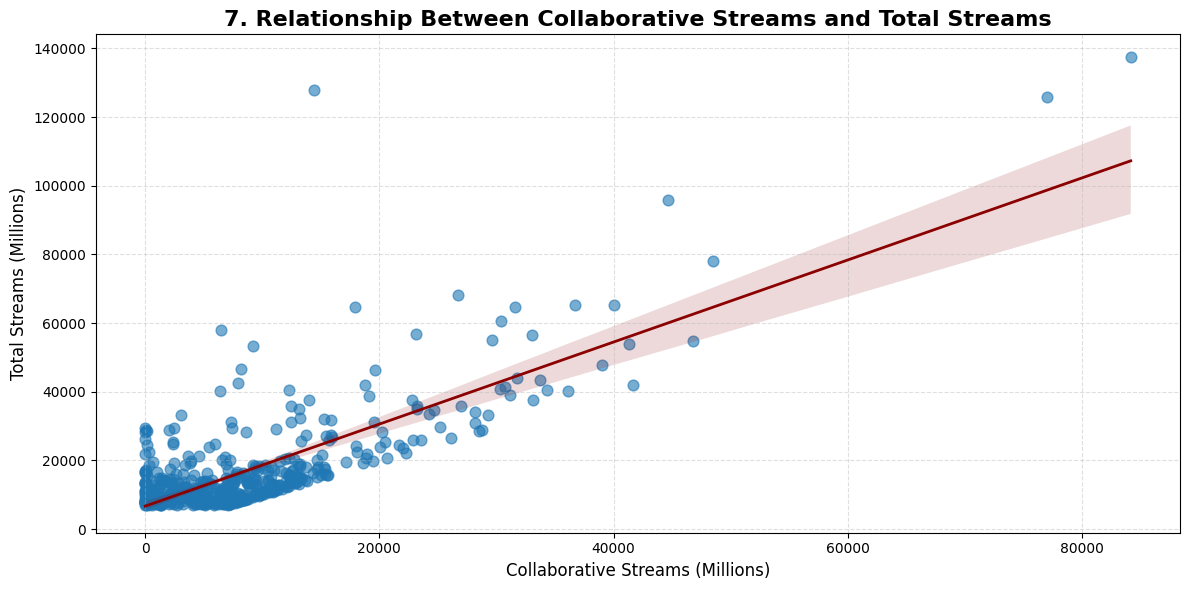

In [19]:
fig = plt.figure(figsize=(12, 6))
sns.regplot(
    data=df,
    x='Collaborative Streams (in millions)',
    y='Total Streams (in millions)',
    scatter_kws={
        'alpha': 0.6,
        's': 60},
    line_kws={
        'color': 'darkred',
        'linewidth': 2})
plt.title(
    f'{plot_no}. Relationship Between Collaborative Streams and Total Streams',
    fontsize=16,
    fontweight='bold')
plt.xlabel('Collaborative Streams (Millions)', fontsize=12)
plt.ylabel('Total Streams (Millions)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
show_fig()
plot_no += 1

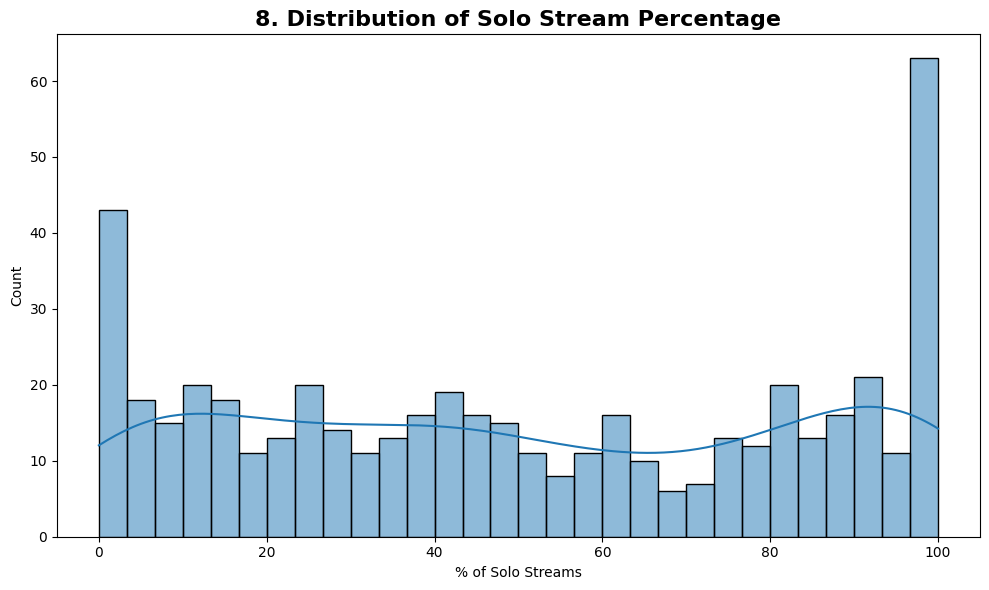

In [20]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['% of Solo Streams'], bins=30, kde=True)
plt.title(f'{plot_no}. Distribution of Solo Stream Percentage',fontsize=16,fontweight='bold')
show_fig()
plot_no += 1

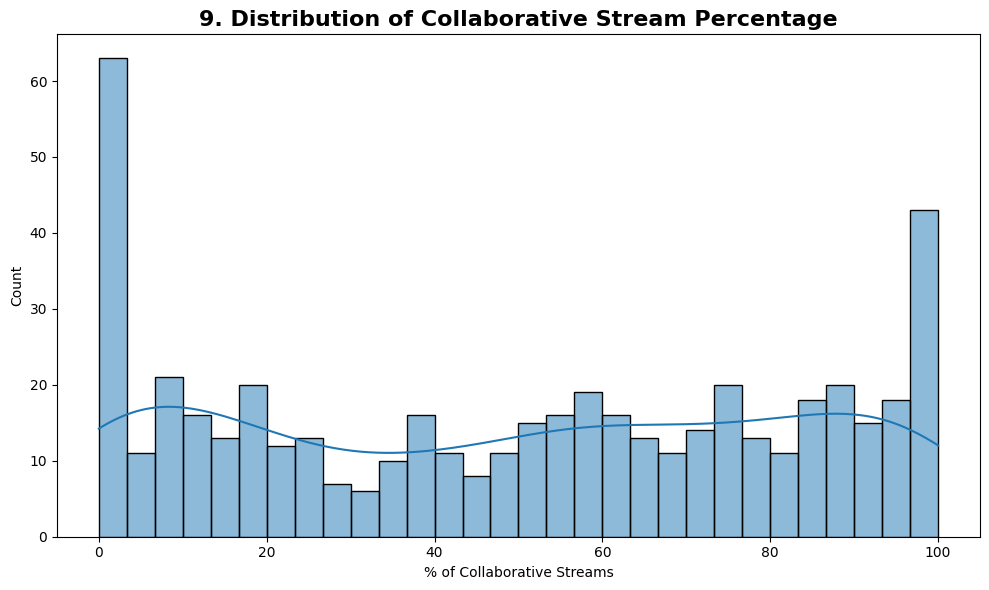

In [21]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['% of Collaborative Streams'], bins=30, kde=True)
plt.title(f'{plot_no}. Distribution of Collaborative Stream Percentage',fontsize=16,fontweight='bold')
show_fig()
plot_no += 1

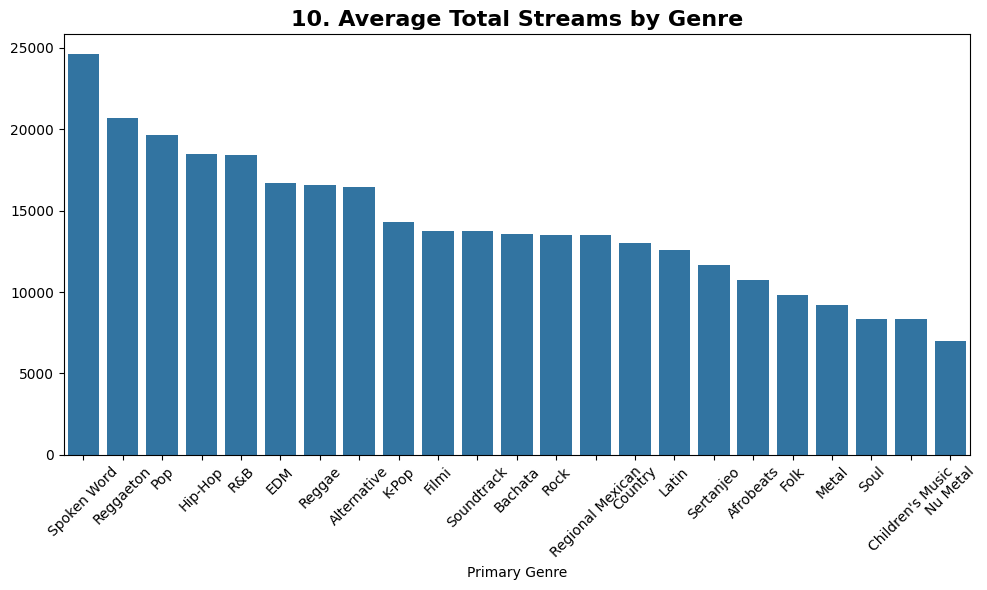

In [22]:
fig = plt.figure(figsize=(10,6))
top_genres = df.groupby('Primary Genre')['Total Streams (in millions)'].mean().sort_values(ascending=False)
sns.barplot(x=top_genres.index, y=top_genres.values)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Average Total Streams by Genre',fontsize=16,fontweight='bold')
show_fig()
plot_no += 1

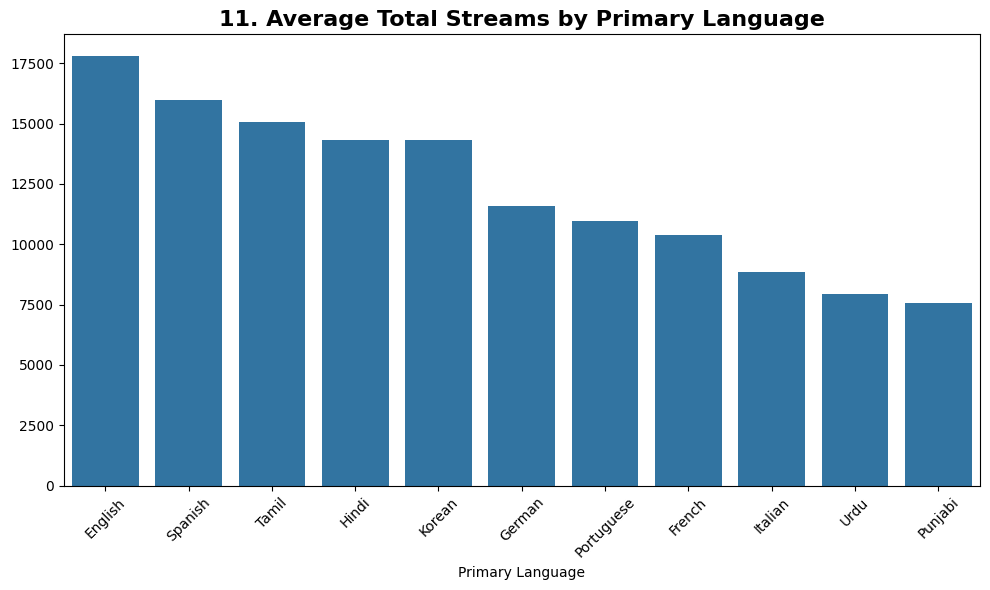

In [23]:
fig = plt.figure(figsize=(10,6))
top_languages = df.groupby('Primary Language')['Total Streams (in millions)'].mean().sort_values(ascending=False)
sns.barplot(x=top_languages.index, y=top_languages.values)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Average Total Streams by Primary Language',fontsize=16,fontweight='bold')
show_fig()
plot_no += 1

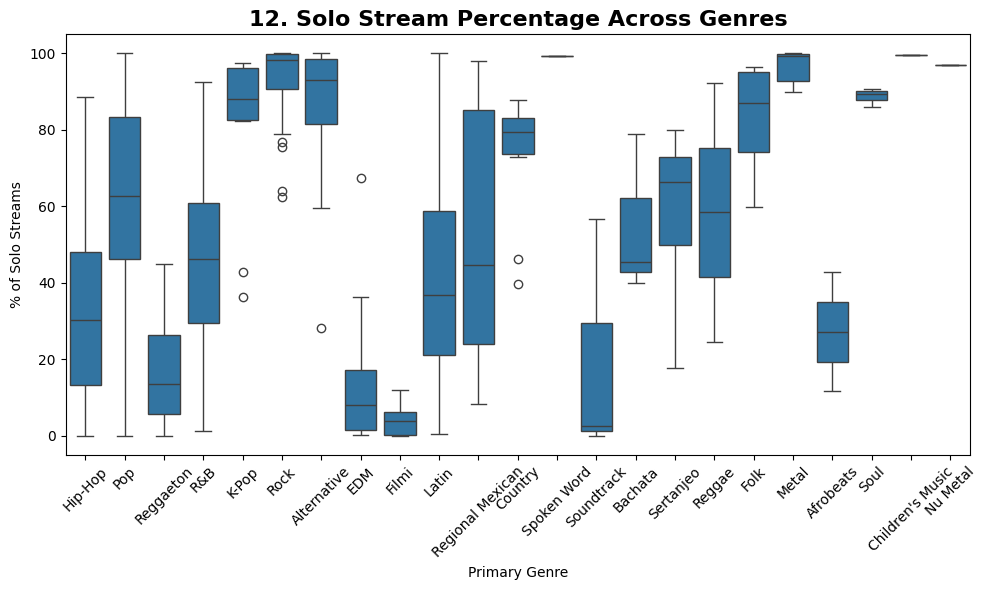

In [24]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Primary Genre', y='% of Solo Streams')
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Solo Stream Percentage Across Genres',fontsize=16,fontweight='bold')
show_fig()
plot_no += 1

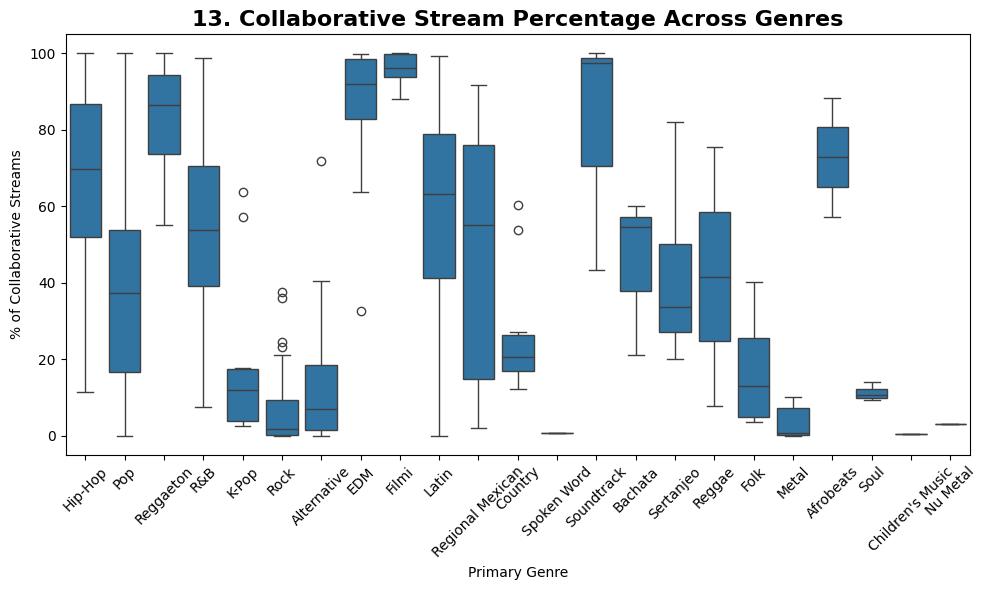

In [25]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Primary Genre', y='% of Collaborative Streams')
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Collaborative Stream Percentage Across Genres',fontsize=16,fontweight='bold')
show_fig()
plot_no += 1

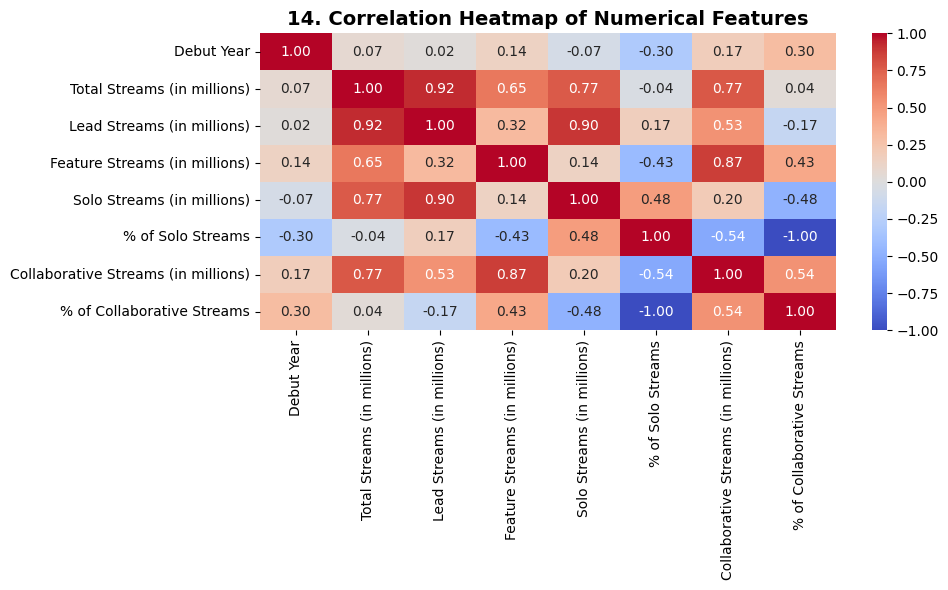

In [26]:
corr = df.select_dtypes(include='number').corr()
fig = plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Features',fontsize=14,fontweight='bold')
show_fig()
plot_no += 1

## Predictive Analysis

In [27]:
from sklearn.model_selection import train_test_split



from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor 
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor 
from sklearn.svm import SVR 

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd 

# -------------------------------
# Linear Regression: Predict Total Streams
# -------------------------------

# Features (Predictors)
predictor_cols = [
    'Lead Streams (in millions)',
    'Feature Streams (in millions)',
    'Solo Streams (in millions)'
]

target_col = 'Total Streams (in millions)'

data = df[predictor_cols + [target_col]].dropna()
X = data[predictor_cols]
y = data[target_col]

X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.20 , random_state = 42)



#Applying all the regression models 

models = {
    "Linear Regression" : LinearRegression() ,
    "Decision Tree" : DecisionTreeRegressor(random_state = 42),
    "Random Forest" : RandomForestRegressor(n_estimators = 100 , random_state = 42),
    "KNN" : KNeighborsRegressor(n_neighbors = 5),
    "SVR" : SVR()
}


results = [] 


#Training the model 

for name,model in  models.items() : 
    model.fit(X_train , y_train) 
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test , y_pred) 
    mae = mean_absolute_error(y_test , y_pred) 
    rmse = np.sqrt(mean_squared_error(y_test , y_pred))

    results.append({
        "Model" : name , 
        "R2 Score" : round(r2 , 3) , 
        "MAE" : round(mae , 2) , 
        "RMSE" : round(rmse , 2) 
    })


results_df = pd.DataFrame(results) 
results_df = results_df.sort_values("R2 Score" , ascending = False)

print(results_df)

               Model  R2 Score       MAE      RMSE
0  Linear Regression     1.000      5.33      7.53
2      Random Forest     0.894   1625.17   6502.42
1      Decision Tree     0.890   2110.83   6631.16
3                KNN     0.824   2178.64   8388.19
4                SVR    -0.103  10117.53  20982.94
